# 🌱 Visão Computacional aplicada ao monitoramento de elementos de interesse agrícola

## 🌾 1. Contextualização

O agronegócio possui grande importância econômica em Goiás, estado marcado pela forte presença da produção agrícola e pecuária. Em grandes áreas de produção, o monitoramento visual do ambiente pode ser uma tarefa difícil quando realizado exclusivamente de forma manual.

Nesse contexto, técnicas de **Inteligência Artificial 🤖** e **Visão Computacional 👁️** podem auxiliar na análise automatizada de imagens, permitindo que sistemas aprendam padrões visuais e realizem classificações de forma automática.

Neste projeto, utilizaremos o dataset **CIFAR-100** e uma **Rede Neural Convolucional (CNN)** para investigar a capacidade de um modelo de Deep Learning em classificar diferentes grupos de organismos e elementos presentes em ambientes naturais e rurais.

## 🎯 2. Problema

Em ambientes agrícolas, diferentes organismos e elementos do ecossistema podem estar presentes nas áreas de produção. A identificação visual desses elementos pode representar uma etapa inicial de monitoramento e triagem.

Assim, buscamos investigar:

> **Até que ponto uma Rede Neural Convolucional é capaz de classificar automaticamente imagens de categorias de interesse agrícola utilizando o dataset CIFAR-100?**

## 🚀 3. Objetivo

Desenvolver e avaliar um modelo de Inteligência Artificial capaz de classificar imagens pertencentes a categorias selecionadas do CIFAR-100, utilizando uma Rede Neural Convolucional.

## 🌿 4. Categorias selecionadas

Foram selecionadas oito categorias do CIFAR-100 que possuem relação com organismos e elementos de ambientes naturais e agrícolas:

🌳 Trees  
🍎 Fruit and vegetables  
🐛 Insects  
🕷️ Non-insect invertebrates  
🐭 Small mammals  
🦊 Medium mammals  
🐗 Large omnivores and herbivores  
🐍 Reptiles

## ⚠️ 5. Limitação

O CIFAR-100 não é um dataset agrícola. Portanto, o modelo desenvolvido não será considerado um detector real de pragas, doenças ou danos em plantações.

O objetivo é utilizar o dataset como uma **prova de conceito**, investigando como técnicas de classificação de imagens podem ser aplicadas a um problema contextualizado no ambiente agrícola.

## 🔄 6. Pipeline

📦 Dados → 🧹 Pré-processamento → 🧠 Modelo → 📚 Treinamento → ✅ Validação → 🧪 Teste → 🔮 Inferência

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

# Garantir resultados reproduzíveis
tf.keras.utils.set_random_seed(42)

## 📦 7. Carregamento do CIFAR-100

O CIFAR-100 possui imagens coloridas de **32 × 32 pixels**, organizadas em diferentes categorias.

Nesta etapa, utilizaremos as **superclasses (coarse labels)** do dataset, pois nosso objetivo é trabalhar com oito grupos maiores de interesse.

In [28]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(
    label_mode="coarse"
)

print("Treino:", x_train.shape)
print("Teste :", x_test.shape)
print("Rótulos de treino:", y_train.shape)
print("Rótulos de teste :", y_test.shape)

Treino: (50000, 32, 32, 3)
Teste : (10000, 32, 32, 3)
Rótulos de treino: (50000, 1)
Rótulos de teste : (10000, 1)


In [29]:
# Ordem oficial das 20 superclasses do CIFAR-100

todas_superclasses = [
    "aquatic_mammals",
    "fish",
    "flowers",
    "food_containers",
    "fruit_and_vegetables",
    "household_electrical_devices",
    "household_furniture",
    "insects",
    "large_carnivores",
    "large_man_made_outdoor_things",
    "large_natural_outdoor_scenes",
    "large_omnivores_and_herbivores",
    "medium_mammals",
    "non_insect_invertebrates",
    "people",
    "reptiles",
    "small_mammals",
    "trees",
    "vehicles_1",
    "vehicles_2"
]

## 🌱 8. Seleção das categorias

Para este projeto, selecionamos oito das vinte superclasses do CIFAR-100.

A seleção foi realizada buscando categorias relacionadas a organismos e elementos que podem estar presentes em ambientes naturais e rurais.

In [30]:
# Nossas 8 categorias
nomes_classes = [
    "Frutas e vegetais",
    "Insetos",
    "Grandes onívoros e herbívoros",
    "Mamíferos de médio porte",
    "Invertebrados não insetos",
    "Répteis",
    "Pequenos mamíferos",
    "Árvores"
]

# Índices correspondentes às superclasses selecionadas
indices_classes = [
    todas_superclasses.index("fruit_and_vegetables"),
    todas_superclasses.index("insects"),
    todas_superclasses.index("large_omnivores_and_herbivores"),
    todas_superclasses.index("medium_mammals"),
    todas_superclasses.index("non_insect_invertebrates"),
    todas_superclasses.index("reptiles"),
    todas_superclasses.index("small_mammals"),
    todas_superclasses.index("trees")
]

for i, classe in enumerate(nomes_classes):
    print(f"{i} → {classe}")

0 → Frutas e vegetais
1 → Insetos
2 → Grandes onívoros e herbívoros
3 → Mamíferos de médio porte
4 → Invertebrados não insetos
5 → Répteis
6 → Pequenos mamíferos
7 → Árvores


## 🔎 9. Construção do conjunto de dados do projeto

O CIFAR-100 completo possui 20 superclasses. Nesta etapa, serão mantidas somente as imagens pertencentes às oito categorias selecionadas.

Assim, construímos um conjunto de dados específico para o problema proposto.

In [31]:
# Selecionar somente as imagens das categorias escolhidas

mask_train = np.isin(y_train.flatten(), indices_classes)
mask_test = np.isin(y_test.flatten(), indices_classes)

x_train_projeto = x_train[mask_train]
y_train_projeto_original = y_train[mask_train]

x_test_projeto = x_test[mask_test]
y_test_projeto_original = y_test[mask_test]

print("Treino do projeto:", x_train_projeto.shape)
print("Teste do projeto :", x_test_projeto.shape)

Treino do projeto: (20000, 32, 32, 3)
Teste do projeto : (4000, 32, 32, 3)


In [32]:
# Converter os índices originais das 8 categorias
# para índices de 0 a 7

novo_mapa = {
    indice_original: novo_indice
    for novo_indice, indice_original in enumerate(indices_classes)
}

y_train_projeto = np.array([
    novo_mapa[label[0]]
    for label in y_train_projeto_original
])

y_test_projeto = np.array([
    novo_mapa[label[0]]
    for label in y_test_projeto_original
])

print("Menor rótulo:", y_train_projeto.min())
print("Maior rótulo:", y_train_projeto.max())

Menor rótulo: 0
Maior rótulo: 7


## 📊 10. Distribuição das classes

Antes do treinamento, vamos verificar a quantidade de imagens disponível em cada categoria.

Uma distribuição equilibrada é importante para evitar que o modelo seja favorecido por uma determinada classe.

In [33]:
contagens = np.bincount(
    y_train_projeto,
    minlength=len(nomes_classes)
)

for i, quantidade in enumerate(contagens):
    print(f"{nomes_classes[i]:35s}: {quantidade} imagens")

Frutas e vegetais                  : 2500 imagens
Insetos                            : 2500 imagens
Grandes onívoros e herbívoros      : 2500 imagens
Mamíferos de médio porte           : 2500 imagens
Invertebrados não insetos          : 2500 imagens
Répteis                            : 2500 imagens
Pequenos mamíferos                 : 2500 imagens
Árvores                            : 2500 imagens


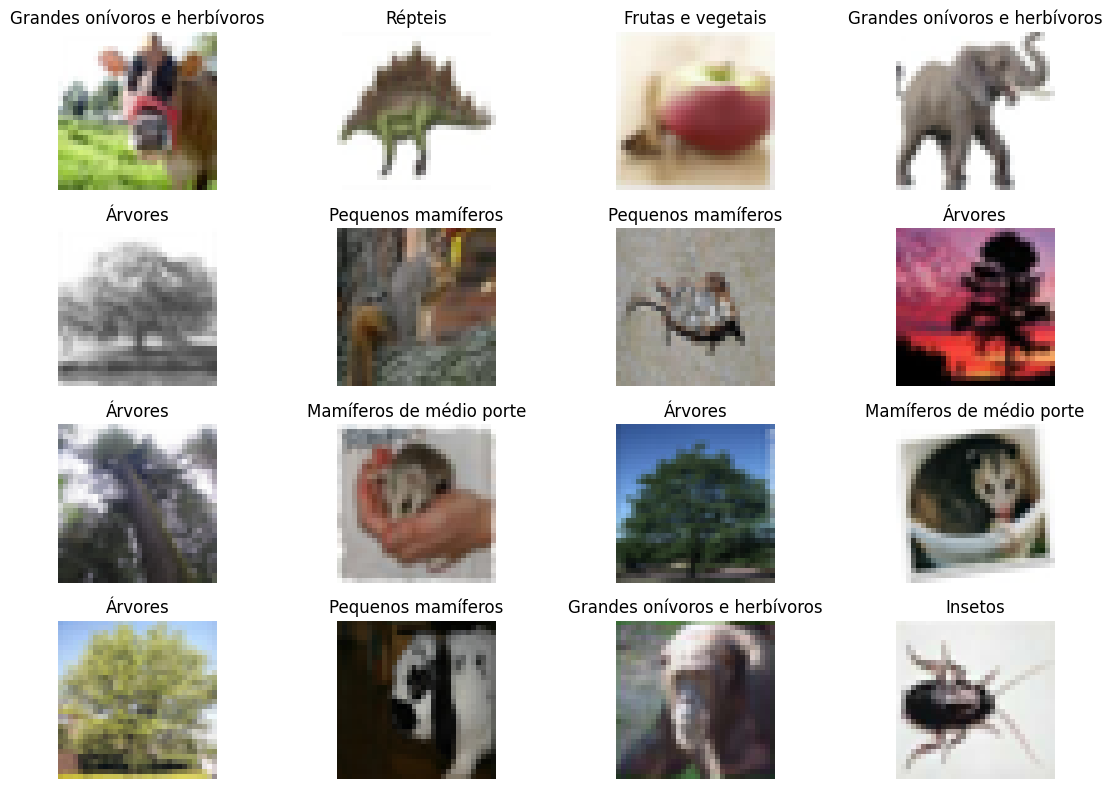

In [34]:
plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(x_train_projeto[i])
    plt.title(nomes_classes[y_train_projeto[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

## 🧹 11. Pré-processamento

As imagens possuem valores de pixel entre 0 e 255.

Para facilitar o treinamento da rede neural, esses valores serão normalizados para o intervalo entre 0 e 1.

Para isso, dividimos os pixels por 255.

In [35]:
x_train_projeto = x_train_projeto.astype("float32") / 255.0
x_test_projeto = x_test_projeto.astype("float32") / 255.0

print("Valor mínimo:", x_train_projeto.min())
print("Valor máximo:", x_train_projeto.max())

Valor mínimo: 0.0
Valor máximo: 1.0


## 🧠 12. Construção da Rede Neural Convolucional

Uma CNN é adequada para classificação de imagens porque suas camadas convolucionais conseguem aprender padrões espaciais presentes nos pixels.

A arquitetura será composta por camadas de convolução, redução espacial e classificação.

In [36]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Primeira etapa de extração de características
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Segunda etapa
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Terceira etapa
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),

    # Transformar características em vetor
    tf.keras.layers.Flatten(),

    # Camada de classificação
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    # Saída: 8 categorias
    tf.keras.layers.Dense(8, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,552 (1.36 MB)

 Trainable params: 356,552 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 📚 13. Treinamento

O modelo será treinado utilizando 80% dos dados para treinamento e 20% para validação.

Utilizaremos 15 épocas para acompanhar a evolução do aprendizado e observar o comportamento das curvas de treinamento e validação.

In [38]:
history = model.fit(
    x_train_projeto,
    y_train_projeto,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.3232 - loss: 1.7816 - val_accuracy: 0.4105 - val_loss: 1.5818
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.4264 - loss: 1.5486 - val_accuracy: 0.4658 - val_loss: 1.4323
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 75ms/step - accuracy: 0.4704 - loss: 1.4358 - val_accuracy: 0.4975 - val_loss: 1.3571
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.5082 - loss: 1.3368 - val_accuracy: 0.5205 - val_loss: 1.3542
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5424 - loss: 1.2530 - val_accuracy: 0.5415 - val_loss: 1.2933
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5729 - loss: 1.1729 - val_accuracy: 0.5472 - val_loss: 1.2563
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.5915 - loss: 1.1158 - val_accuracy: 0.5422 - val_loss: 1.3089
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.6223 - loss: 1.0347 - 

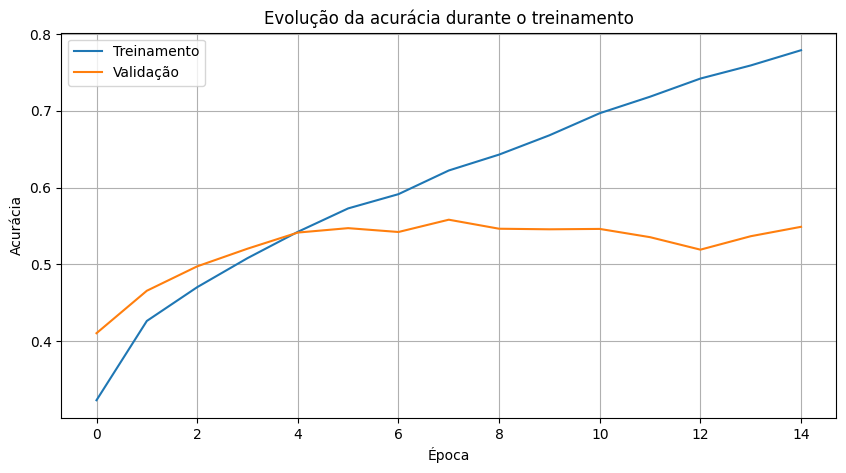

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Treinamento"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Evolução da acurácia durante o treinamento")
plt.legend()
plt.grid(True)

plt.show()

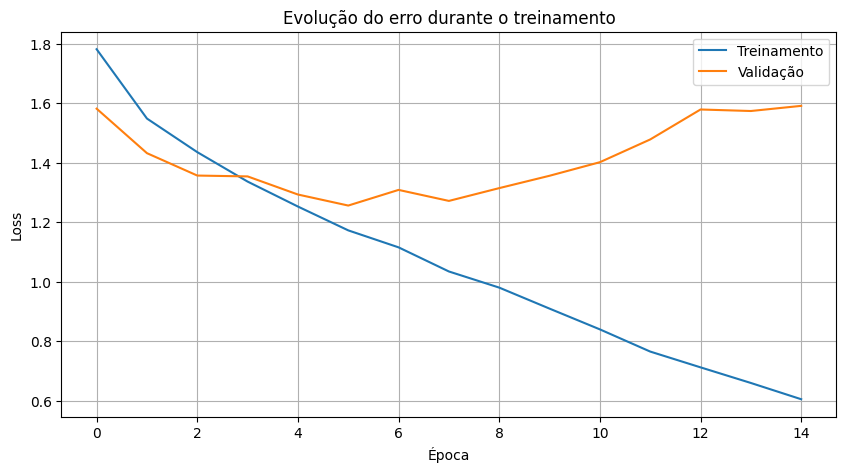

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Treinamento"
)

plt.plot(
    history.history["val_loss"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolução do erro durante o treinamento")
plt.legend()
plt.grid(True)

plt.show()

## 📊 14. Avaliação do modelo

Após o treinamento, o modelo será avaliado utilizando o conjunto de teste, composto por imagens que não foram utilizadas diretamente no treinamento.

A acurácia no teste será utilizada como principal medida de desempenho global.

In [41]:
test_loss, test_accuracy = model.evaluate(
    x_test_projeto,
    y_test_projeto,
    verbose=1
)

print(f"\n📊 Acurácia no teste: {test_accuracy:.2%}")
print(f"📉 Loss no teste: {test_loss:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5443 - loss: 1.6004

📊 Acurácia no teste: 54.43%
📉 Loss no teste: 1.6004


In [42]:
# Gerar previsões para todo o conjunto de teste

y_pred_prob = model.predict(
    x_test_projeto,
    verbose=1
)

# Escolher a classe com maior probabilidade
y_pred = np.argmax(y_pred_prob, axis=1)

print("Previsões realizadas:", len(y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Previsões realizadas: 4000


## 🧩 15. Matriz de confusão

A matriz de confusão permite visualizar como as previsões do modelo se distribuem entre as oito categorias.

A diagonal principal representa as classificações corretas, enquanto os demais elementos representam confusões entre categorias.

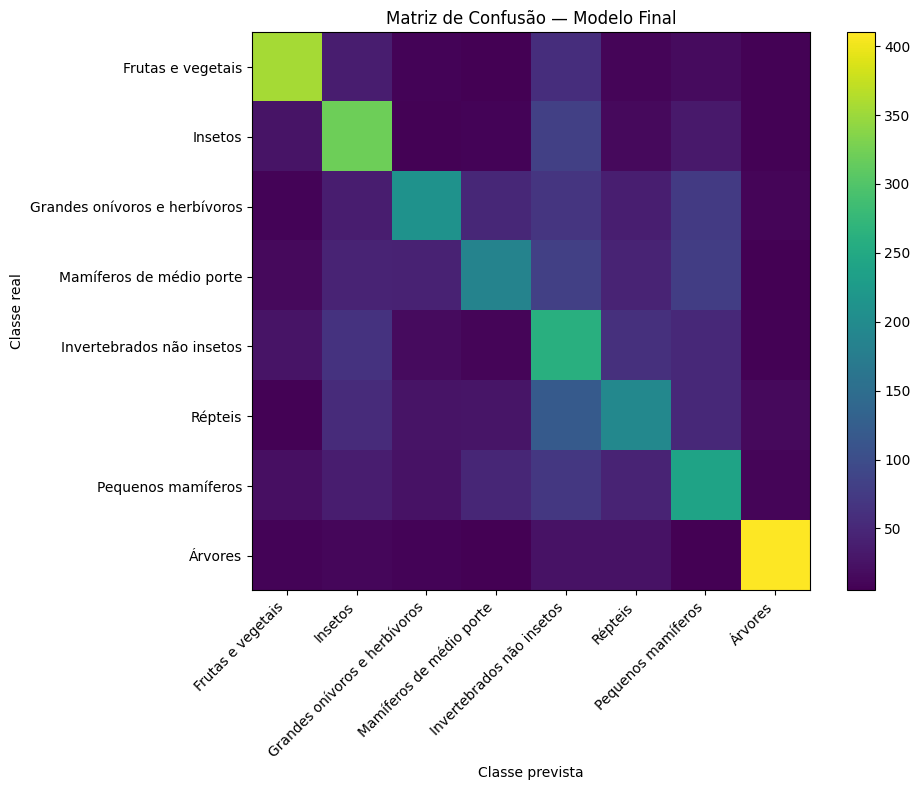

In [43]:
cm = confusion_matrix(
    y_test_projeto,
    y_pred
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Matriz de Confusão — Modelo Final")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.xticks(
    range(8),
    nomes_classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(8),
    nomes_classes
)

plt.colorbar()

plt.tight_layout()
plt.show()

## 📋 16. Relatório de classificação

Além da acurácia geral, serão analisadas métricas individuais de cada categoria.

O relatório apresenta:

🎯 **Precision** — proporção das previsões de uma classe que estavam corretas.

🔎 **Recall** — proporção dos exemplos de uma classe que foram corretamente identificados.

⚖️ **F1-score** — combinação entre precision e recall.

In [44]:
print(
    classification_report(
        y_test_projeto,
        y_pred,
        target_names=nomes_classes,
        zero_division=0
    )
)

                               precision    recall  f1-score   support

            Frutas e vegetais       0.75      0.71      0.73       500
                      Insetos       0.53      0.64      0.58       500
Grandes onívoros e herbívoros       0.60      0.42      0.50       500
     Mamíferos de médio porte       0.54      0.37      0.44       500
    Invertebrados não insetos       0.34      0.52      0.41       500
                      Répteis       0.44      0.39      0.41       500
           Pequenos mamíferos       0.44      0.48      0.46       500
                      Árvores       0.86      0.82      0.84       500

                     accuracy                           0.54      4000
                    macro avg       0.56      0.54      0.55      4000
                 weighted avg       0.56      0.54      0.55      4000



## ❌ 17. Análise dos erros

Além das métricas numéricas, é importante observar exemplos em que o modelo realizou classificações incorretas.

Essa análise permite identificar visualmente algumas das dificuldades encontradas durante a classificação.

In [45]:
erros = np.where(
    y_pred != y_test_projeto
)[0]

print(f"Quantidade de classificações incorretas: {len(erros)}")

Quantidade de classificações incorretas: 1823


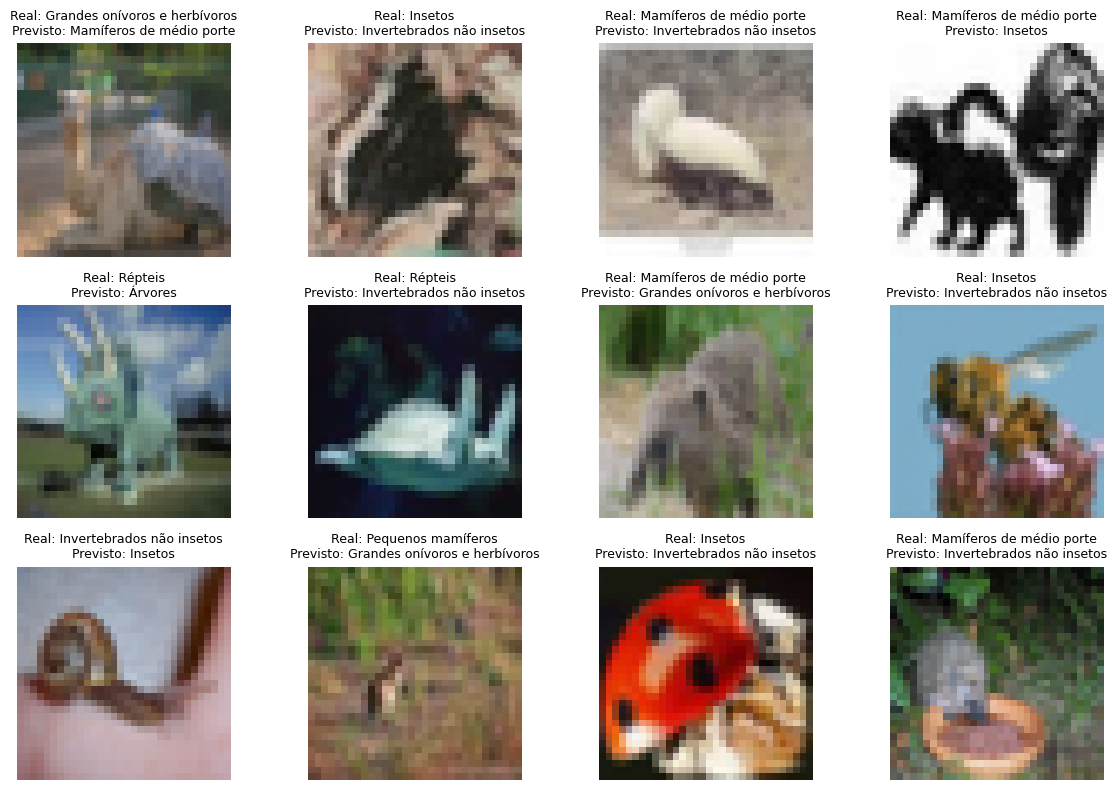

In [46]:
plt.figure(figsize=(12, 8))

quantidade = min(12, len(erros))

for i in range(quantidade):

    indice = erros[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test_projeto[indice])

    real = nomes_classes[y_test_projeto[indice]]
    previsto = nomes_classes[y_pred[indice]]

    plt.title(
        f"Real: {real}\nPrevisto: {previsto}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## ✅ 18. Exemplos de classificações corretas

Também serão observados exemplos em que o modelo realizou a classificação corretamente.

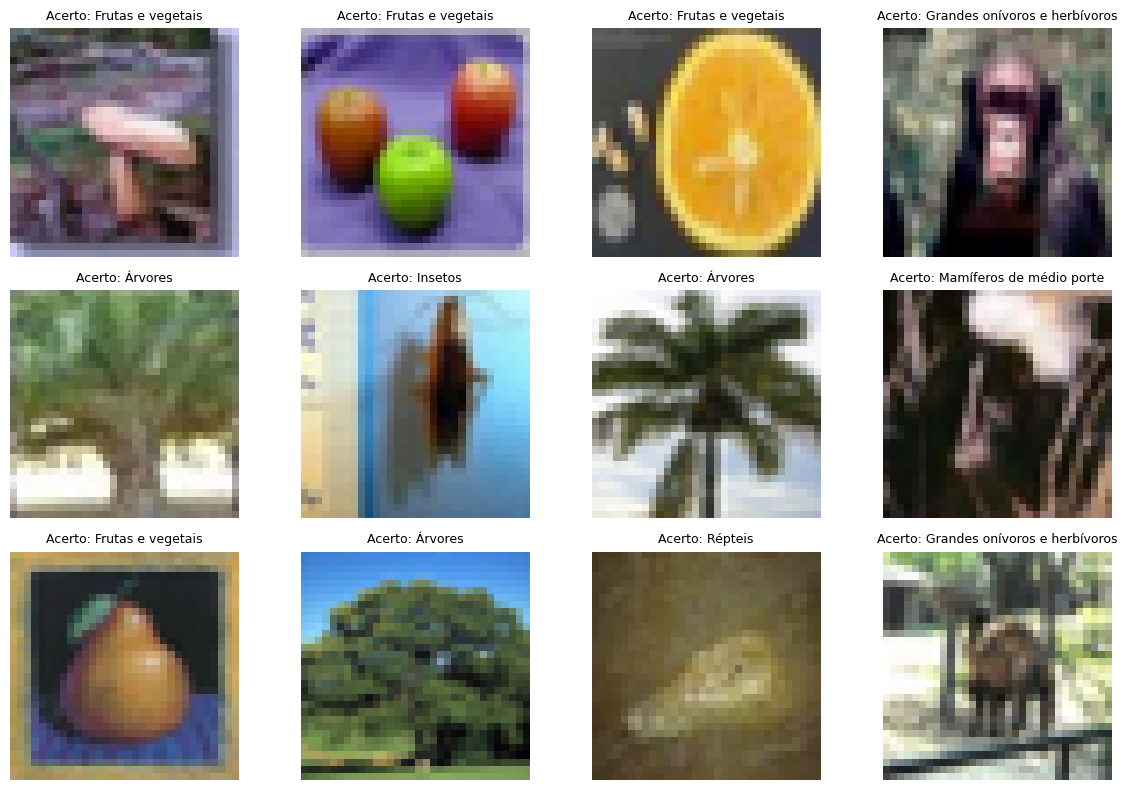

In [47]:
acertos = np.where(
    y_pred == y_test_projeto
)[0]

plt.figure(figsize=(12, 8))

quantidade = min(12, len(acertos))

for i in range(quantidade):

    indice = acertos[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test_projeto[indice])

    classe = nomes_classes[y_test_projeto[indice]]

    plt.title(
        f"Acerto: {classe}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 🔮 19. Inferência

Por fim, vamos realizar uma previsão utilizando uma imagem do conjunto de teste.

A imagem não foi utilizada diretamente durante o treinamento da rede, permitindo observar a previsão produzida pelo modelo.

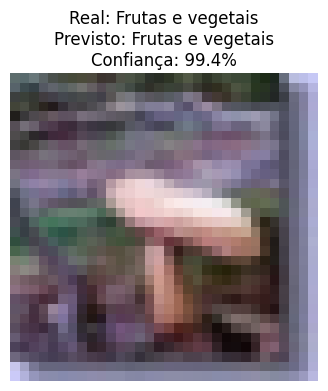

In [48]:
indice = 0

imagem = x_test_projeto[indice]

classe_real = nomes_classes[
    y_test_projeto[indice]
]

imagem_entrada = np.expand_dims(
    imagem,
    axis=0
)

previsao = model.predict(
    imagem_entrada,
    verbose=0
)

classe_prevista = np.argmax(previsao)

confianca = np.max(previsao)

plt.figure(figsize=(4, 4))

plt.imshow(imagem)
plt.axis("off")

plt.title(
    f"Real: {classe_real}\n"
    f"Previsto: {nomes_classes[classe_prevista]}\n"
    f"Confiança: {confianca:.1%}"
)

plt.show()

# 🏁 20. Conclusão

Neste projeto, desenvolvemos uma Rede Neural Convolucional utilizando TensorFlow/Keras para classificar imagens de oito categorias selecionadas do dataset CIFAR-100.

O desenvolvimento seguiu o pipeline de classificação de imagens trabalhado em aula:

📦 carregamento dos dados  
🔎 seleção das categorias  
🧹 pré-processamento  
🧠 construção da CNN  
📚 treinamento  
✅ validação  
🧪 teste  
📊 avaliação  
🧩 matriz de confusão  
❌ análise dos erros  
🔮 inferência

O modelo apresentou uma acurácia de **54,43%** no conjunto de teste.

A análise das curvas de treinamento e validação permitiu observar a evolução do aprendizado e identificar possíveis diferenças entre o desempenho nos dados de treinamento e nos dados de validação.

A matriz de confusão e o relatório de classificação permitiram analisar o comportamento do modelo individualmente em cada categoria, mostrando quais grupos apresentam maior facilidade ou dificuldade de classificação.

🌱 Embora o CIFAR-100 não seja um dataset agrícola, o projeto demonstra como técnicas de Visão Computacional podem ser utilizadas para classificação automática de imagens dentro de um problema contextualizado.

Para uma aplicação agrícola real, seria necessário utilizar um dataset específico, contendo imagens de campo e categorias relacionadas diretamente às situações que se deseja monitorar.

Assim, o projeto funciona como uma **prova de conceito**, demonstrando a aplicação prática de uma Rede Neural Convolucional em um problema de classificação de imagens.